# NPC Brain

Logique LLM dans le notebook. Pygame tourne dans un **subprocess** (`npc_viewer.py`) pour éviter le crash SDL sur Windows.

**Workflow :**
1. Placer `npc_viewer.py` dans le même dossier que ce notebook
2. Exécuter toutes les cellules dans l'ordre
3. La dernière cellule lance le viewer + la simulation

In [1]:
import numpy as np
import os, time, json, subprocess, sys, random, re, datetime
from enum import Enum
from typing import Optional
from pathlib import Path

from openai import OpenAI
from dotenv import load_dotenv
from pydantic import BaseModel
from npc_solver import optimal_collect

## Config LLM

In [2]:
load_dotenv()
LLM_API_URL   = os.environ["LLM_API_URL"]
LLM_API_TOKEN = os.environ["LLM_API_TOKEN"]
MODEL         = "mistralai/ministral-3-3b"

client = OpenAI(base_url=LLM_API_URL, api_key=LLM_API_TOKEN)
print("Client LLM prêt.")


Client LLM prêt.


## Modélisation du monde

In [3]:
VOID   = 0
PLAYER = 1
ENEMY  = 2
GOLD   = 3

# INITIAL_MAP = np.array([
#     [0, 3, 0, 0, 0, 0, 0],
#     [0, 1, 0, 0, 2, 0, 3],
#     [0, 3, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0, 3],
#     [0, 0, 0, 0, 0, 0, 0],
# ])

def make_random_map(n_rows=8, n_cols=8, n_gold=6, n_enemy=10, seed=None):
    rng = np.random.default_rng(seed)
    grid = np.zeros((n_rows, n_cols), dtype=int)

    # Tire des positions uniques sans collision
    total = n_rows * n_cols
    n_entities = 1 + n_gold + n_enemy  # 1 joueur
    flat_positions = rng.choice(total, size=n_entities, replace=False)

    coords = [(p // n_cols, p % n_cols) for p in flat_positions]

    grid[coords[0]] = PLAYER
    for c in coords[1:1 + n_gold]:
        grid[c] = GOLD
    for c in coords[1 + n_gold:]:
        grid[c] = ENEMY

    return grid

INITIAL_MAP = make_random_map()

## Couche de contrat

In [4]:
class Direction(str, Enum):
    UP    = "UP"
    DOWN  = "DOWN"
    LEFT  = "LEFT"
    RIGHT = "RIGHT"

class PlayerDecision(BaseModel):
    reason: str
    direction: Direction

MOVES = {
    "UP":    (-1,  0),
    "DOWN":  ( 1,  0),
    "LEFT":  ( 0, -1),
    "RIGHT": ( 0,  1),
}


## Moteurs (perception + déplacement)

In [5]:
def localize(world_map, entity):
    return np.argwhere(world_map == entity)

def compute_distances(entities_positions, reference_pos):
    if len(entities_positions) == 0:
        return np.array([])
    v = entities_positions - reference_pos
    return np.round(np.linalg.norm(v, axis=1), 2)

def allowed_move(world_map, pos):
    r, c = pos
    n_rows, n_cols = world_map.shape
    if r < 0 or c < 0 or r >= n_rows or c >= n_cols:
        return False
    return world_map[r, c] in (VOID, GOLD)

def move(world_map, old_pos, new_pos):
    if not allowed_move(world_map, new_pos):
        return tuple(old_pos), False
    gold_collected = bool(world_map[new_pos[0], new_pos[1]] == GOLD)
    entity = world_map[old_pos[0], old_pos[1]]
    world_map[old_pos[0], old_pos[1]] = VOID
    world_map[new_pos[0], new_pos[1]] = entity
    return tuple(new_pos), gold_collected

def perception(world_map):
    player_pos  = localize(world_map, PLAYER)[0]
    golds_pos   = localize(world_map, GOLD)
    enemies_pos = localize(world_map, ENEMY)

    golds_dist   = compute_distances(golds_pos,   player_pos)
    enemies_dist = compute_distances(enemies_pos, player_pos)

    if len(golds_dist) > 0:
        nearest_idx = np.argmin(golds_dist)
        delta = golds_pos[nearest_idx] - player_pos
        nearest_gold_delta = {"row": int(delta[0]), "col": int(delta[1])}
    else:
        nearest_gold_delta = {"row": 0, "col": 0}

    # Perception "physique" : quelles directions sont franchissables ?
    # (on ne dit PAS laquelle prendre -> c'est au LLM de naviguer)
    valid_directions = [
        name for name, (dr, dc) in MOVES.items()
        if allowed_move(world_map, (player_pos[0] + dr, player_pos[1] + dc))
    ]

    return {
        "player_pos":         [int(player_pos[0]), int(player_pos[1])],
        "nearest_gold_delta": nearest_gold_delta,
        "valid_directions":   valid_directions,
        "golds_count":        int(len(golds_dist)),
        "enemies_count":      int(len(enemies_dist)),
    }


## Moteur de décision (LLM)

In [6]:
def decide(player_perception: dict, move_history: list, feedback: str = "") -> Optional[PlayerDecision]:
    delta = player_perception["nearest_gold_delta"]
    valid = player_perception["valid_directions"]

    prompt = f"""/no_think
Tu controles un joueur sur une grille. Objectif : atteindre l'or.

# Ou est l'or le plus proche (par rapport a toi)
- {abs(delta['row'])} case(s) vers {'le DOWN' if delta['row'] > 0 else 'le UP' if delta['row'] < 0 else '(aligne verticalement)'}
- {abs(delta['col'])} case(s) vers {'la DROITE' if delta['col'] > 0 else 'la LEFT' if delta['col'] < 0 else '(aligne horizontalement)'}

# Directions ou tu peux avancer (les seules autorisees)
{valid}

# Tes 5 derniers coups
{move_history[-5:] if move_history else "aucun"}
{feedback}

# Consignes
- Choisis UNE direction parmi {valid}.
- Reduis d'abord le plus grand ecart (vertical ou horizontal).
- Si tu tournes en rond, essaie une autre direction que d'habitude.

Ta reponse : une seule direction."""

    try:
        response = client.beta.chat.completions.parse(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            response_format=PlayerDecision,
            temperature=1,
        )
        return response.choices[0].message.parsed or None
    except Exception as e:
        print(f"[LLM ERROR] {e}")
        return None


## Fichier d'état partagé

Le notebook écrit `npc_state.json`. Le viewer Pygame le lit en boucle.

In [7]:
# Le viewer lit TOUJOURS ce fichier -> nom fixe
STATE_FILE = Path("npc_state.json")

# Fichier de log horodate par run (nom du modele nettoye : / et : interdits)
_safe_model = re.sub(r"[^0-9A-Za-z._-]", "_", MODEL)
RUN_LOG_FILE = Path(f"runs/run_{_safe_model}_{datetime.datetime.now():%Y-%m-%d_%H-%M-%S}.json")
RUN_LOG_FILE.parent.mkdir(exist_ok=True)

def write_state(world_map, score, total_gold, turn, status, decision_log):
    """Etat courant pour le viewer. decision_log est la SEULE source de verite
    pour l'historique (plus de move_history ni log_lines redondants)."""
    state = {
        "model":        MODEL,
        "world_map":    world_map.tolist(),
        "score":        int(score),
        "total_gold":   int(total_gold),
        "turn":         int(turn),
        "status":       status,
        "decision_log": list(decision_log[-8:]),   # {turn, direction, reason, blocked, gold}
    }
    STATE_FILE.write_text(json.dumps(state), encoding="utf-8")

def save_run_log(score, total_gold, turn, status, decision_log, initial_map):
    """Run complet + carte initiale + solution optimale (pour comparaison)."""
    optimal = optimal_collect(initial_map)
    full = {
        "model":        MODEL,
        "final_score":  int(score),
        "total_gold":   int(total_gold),
        "turns_used":   int(turn),
        "status":       status,
        "initial_map":  initial_map.tolist(),          # <- indispensable
        "optimal":      {"steps": optimal["steps"],
                         "directions": optimal["directions"]},
        "decision_log": decision_log,
    }
    RUN_LOG_FILE.write_text(json.dumps(full, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Etat temps reel : {STATE_FILE.resolve()}")
print(f"Log du run      : {RUN_LOG_FILE.resolve()}")


Etat temps reel : C:\Users\yahya\projet_ETL\npc_state.json
Log du run      : C:\Users\yahya\projet_ETL\runs\run_mistralai_ministral-3-3b_2026-07-06_12-03-53.json


## Game loop

In [8]:
def run_simulation(initial_map, max_turns=30):
    world_map    = initial_map.copy()
    move_history = []          # interne : sert au prompt (5 derniers coups)
    decision_log = []          # SEULE source de verite : {turn, direction, reason, blocked, gold}
    score        = 0
    total_gold   = int(np.sum(initial_map == GOLD))
    turn         = 0
    status       = "running"

    write_state(world_map, score, total_gold, turn, status, decision_log)

    feedback = ""
    for turn in range(1, max_turns + 1):
        p = perception(world_map)

        if p["golds_count"] == 0:
            status = "won"
            print(f"Victoire ! {score}/{total_gold} en {turn-1} tours")
            write_state(world_map, score, total_gold, turn, status, decision_log)
            break

        status = "thinking"
        write_state(world_map, score, total_gold, turn, status, decision_log)

        decision = decide(p, move_history, feedback)

        if decision is None:
            print(f"[{turn:02d}] Pas de decision")
            decision_log.append({"turn": turn, "direction": "?", "reason": "(pas de decision LLM)",
                                 "blocked": False, "gold": False})
            status = "running"
            write_state(world_map, score, total_gold, turn, status, decision_log)
            continue

        dir_str = decision.direction.value
        reason  = decision.reason.strip()

        player_pos = localize(world_map, PLAYER)[0]
        old_pos    = tuple(player_pos)
        d_row, d_col = MOVES[dir_str]
        new_pos    = (player_pos[0] + d_row, player_pos[1] + d_col)
        new_pos, gold_collected = move(world_map, player_pos, new_pos)
        move_history.append(dir_str)

        blocked = (new_pos == old_pos)

        decision_log.append({
            "turn":      turn,
            "direction": dir_str,
            "reason":    reason,
            "blocked":   blocked,
            "gold":      bool(gold_collected),
        })

        if blocked:
            feedback = f"# ATTENTION\nTon dernier coup {dir_str} etait BLOQUE (mur). Change de direction."
            print(f"[{turn:02d}] {dir_str:7} (bloque) | {reason}")
        elif gold_collected:
            score += 1
            feedback = ""
            print(f"[{turn:02d}] {dir_str:7} +OR score={score}/{total_gold} | {reason}")
        else:
            feedback = ""
            print(f"[{turn:02d}] {dir_str:7} | {reason}")

        status = "won" if score >= total_gold else "running"
        write_state(world_map, score, total_gold, turn, status, decision_log)

        time.sleep(0.05)
    else:
        status = "timeout"
        print(f"Temps ecoule. Score : {score}/{total_gold}")
        write_state(world_map, score, total_gold, turn, status, decision_log)

    save_run_log(score, total_gold, turn, status, decision_log, initial_map)
    return decision_log


## Lancement

Démarre le viewer Pygame en subprocess puis lance la simulation.

In [9]:
viewer_path = Path("npc_viewer.py")

if not viewer_path.exists():
    print(f"ATTENTION : {viewer_path.resolve()} introuvable.")
    print("Pose npc_viewer.py dans le meme dossier que ce notebook.")
else:
    # Lance le viewer dans un vrai process Python (thread principal SDL -> pas de crash)
    proc = subprocess.Popen([sys.executable, str(viewer_path)])
    print(f"Viewer lance (PID {proc.pid})")
    time.sleep(1.5)   # laisse Pygame s'initialiser et lire le premier etat

    run_simulation(INITIAL_MAP, max_turns=30)
    print("Simulation terminee. Ferme la fenetre Pygame quand tu veux.")

Viewer lance (PID 19428)
[01] UP      | Sur la grille actuelle, l’or se situe à -1 case UP et -3 cases LEFT.

Le déplacement le plus pertinent consiste donc à privilégier **UP** (le mouvement vertical réduit le plus grand écart au moment actuel, car la distance en gauche/derrière est déjà minime comparée aux coordonnées optimales : on veut avancer vers les 0 en LEFT).
[02] LEFT    | L'or est à 3 cases à gauche de ma position actuelle et aucune indication n'existe sur un écart vertical actuel. Les options disponibles sont donc LIMITÉMENT ['UP', 'DOWN'] ou bien ['LEFT'].
[03] RIGHT   | La position actuelle du joueur peut être estimée comme suit grâce aux coups précédents (UP + LEFT) et à la localisation de l'or : supposons qu'après les mouvements UP/LEFT le joueur est en position X1, Y1 avec un or à X2 = X1-2 et Y2 proche, c'est-à-dire **en allongeant à droite (RIGHT)** il se rapproche verticalement vers l'or (l'écart horizontal n'est pas résolu comme priorité absolue ici).
[04] DOWN    

# Analyse des runs

Charge un fichier `runs/*.json` (produit par `run_simulation`) et visualise le comportement du LLM :
tableau tour par tour, distribution des directions, coups bloqués, oscillations.


In [10]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

def load_run(path):
    """Charge un run.json -> (meta dict, DataFrame du decision_log)."""
    data = json.loads(Path(path).read_text(encoding="utf-8"))   # règle Windows !
    df = pd.DataFrame(data["decision_log"])
    return data, df

def list_runs(verbose=True):
    """Liste les runs VALIDES, du plus récent au plus ancien.
    Ignore (et signale) les fichiers vides/corrompus au lieu de crasher."""
    valid, skipped = [], []
    for r in sorted(glob.glob("runs/*.json"), reverse=True):
        p = Path(r)
        try:
            txt = p.read_text(encoding="utf-8")
            if not txt.strip():
                skipped.append((r, "fichier vide")); continue
            data = json.loads(txt)
            if "decision_log" not in data:
                skipped.append((r, "pas de decision_log")); continue
            valid.append(r)
        except json.JSONDecodeError as e:
            skipped.append((r, f"JSON invalide ({e.msg})"))
        except UnicodeDecodeError:
            skipped.append((r, "encodage non-UTF8"))
    if verbose:
        for i, r in enumerate(valid):
            data = json.loads(Path(r).read_text(encoding="utf-8"))
            has_map = "carte OK" if "initial_map" in data else "SANS carte"
            print(f"[{i}] {r}  ({has_map})")
        for r, why in skipped:
            print(f"    [ignoré] {r} — {why}")
    return valid

runs = list_runs()

[0] runs\run_mistralai_ministral-3-3b_2026-07-06_12-03-53.json  (carte OK)
[1] runs\run_mistralai_ministral-3-3b_2026-07-06_11-46-31.json  (carte OK)
[2] runs\run_mistralai_ministral-3-3b_2026-07-06_11-38-03.json  (carte OK)
[3] runs\run_mistralai_ministral-3-3b_2026-07-06_11-32-53.json  (carte OK)
[4] runs\run_mistralai_ministral-3-3b_2026-07-06_09-55-05.json  (carte OK)
[5] runs\run_mistralai_ministral-3-3b_2026-07-04_11-02-23.json  (carte OK)
[6] runs\run_mistralai_ministral-3-3b_2026-07-02_19-39-02.json  (carte OK)
[7] runs\run_mistralai_ministral-3-3b_2026-07-02_19-36-08.json  (carte OK)
[8] runs\run_mistralai_ministral-3-3b_2026-07-02_18-26-21.json  (carte OK)
[9] runs\run_mistralai_ministral-3-3b_2026-07-01_20-34-01.json  (carte OK)
[10] runs\run_mistralai_ministral-3-3b_2026-07-01_20-28-35.json  (carte OK)
[11] runs\run_mistralai_ministral-3-3b_2026-07-01_20-26-21.json  (carte OK)
[12] runs\run_mistralai_ministral-3-3b_2026-07-01_20-24-14.json  (carte OK)
[13] runs\run_mistrala

## Charger un run

Change l'index pour choisir un autre run dans la liste ci-dessus.

In [11]:
# Choisis le run a analyser (0 = le plus recent)
run_path = runs[0]

data, df = load_run(run_path)

print(f"Modele : {data['model']}")
print(f"Score  : {data['final_score']}/{data['total_gold']}")
print(f"Tours  : {data['turns_used']}")
print(f"Statut : {data['status']}")
print()

# Tableau tour par tour
df[["turn", "direction", "blocked", "gold", "reason"]]


Modele : mistralai/ministral-3-3b
Score  : 5/6
Tours  : 30
Statut : timeout



,turn,direction,blocked,gold,reason
0,1,UP,False,False,"Sur la grille actuelle, l’or se situe à -1 cas..."
1,2,LEFT,False,False,L'or est à 3 cases à gauche de ma position act...
2,3,RIGHT,False,False,La position actuelle du joueur peut être estim...
3,4,DOWN,False,False,Analyse des contraintes et objectifs :
4,5,UP,False,False,"D'après les informations données, les distance..."
5,6,LEFT,False,False,Analysons les contraintes pour minimiser la di...
6,7,LEFT,False,False,L'or est à **2 cases vers LEFT** et **0 vers l...
7,8,UP,False,False,Analyse des coordonnées et du cheminement opti...
8,9,LEFT,False,False,Analysons les informations disponibles pour at...
9,10,DOWN,False,True,**Solution optimale** : **DOWN**


## Statistiques du run

In [12]:
def count_oscillations(dirs):
    """Compte les motifs A/B/A/B (le joueur fait des allers-retours)."""
    osc = 0
    for i in range(3, len(dirs)):
        if dirs[i] == dirs[i-2] and dirs[i-1] == dirs[i-3] and dirs[i] != dirs[i-1]:
            osc += 1
    return osc

n_moves   = len(df)
n_blocked = int(df["blocked"].sum())
n_gold    = int(df["gold"].sum())
n_osc     = count_oscillations(df["direction"].tolist())

print(f"Coups totaux       : {n_moves}")
print(f"Coups bloques      : {n_blocked}  ({n_blocked/n_moves*100:.0f}%)")
print(f"Or ramasse         : {n_gold}")
print(f"Oscillations A/B/A/B: {n_osc}")
print()
print("Distribution des directions :")
print(df["direction"].value_counts().to_string())


Coups totaux       : 30
Coups bloques      : 1  (3%)
Or ramasse         : 5
Oscillations A/B/A/B: 1

Distribution des directions :
direction
LEFT     11
DOWN      8
UP        7
RIGHT     4


## Visualisations

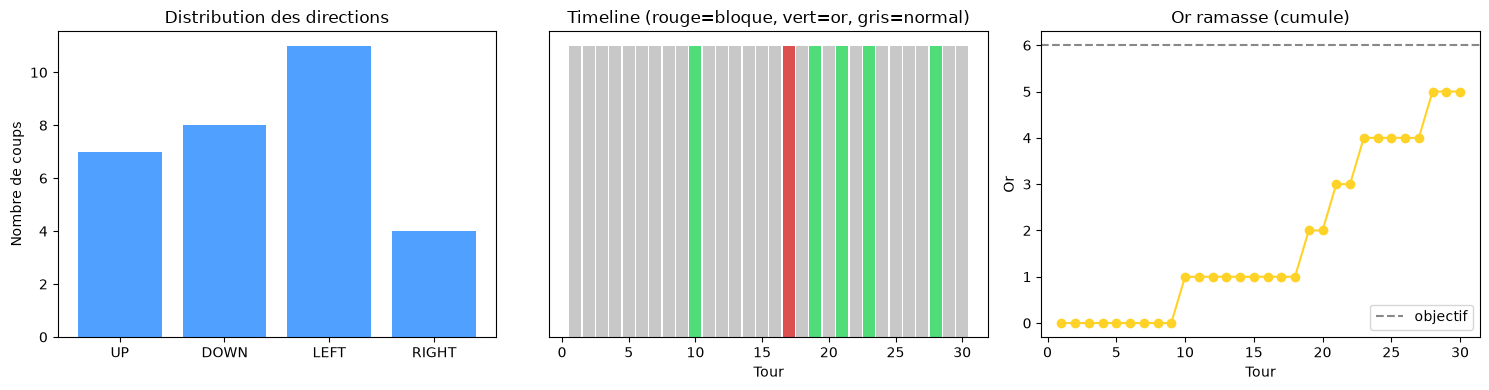

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution des directions
order = ["UP", "DOWN", "LEFT", "RIGHT"]
counts = df["direction"].value_counts().reindex(order, fill_value=0)
axes[0].bar(counts.index, counts.values, color="#50a0ff")
axes[0].set_title("Distribution des directions")
axes[0].set_ylabel("Nombre de coups")

# 2. Timeline des coups (bloque / or / normal)
colors = ["#dc5050" if b else "#50dc78" if g else "#c8c8c8"
          for b, g in zip(df["blocked"], df["gold"])]
axes[1].bar(df["turn"], [1]*len(df), color=colors, width=0.9)
axes[1].set_title("Timeline (rouge=bloque, vert=or, gris=normal)")
axes[1].set_xlabel("Tour")
axes[1].set_yticks([])

# 3. Score cumule au fil des tours
df["cum_gold"] = df["gold"].cumsum()
axes[2].plot(df["turn"], df["cum_gold"], marker="o", color="#ffd228")
axes[2].axhline(data["total_gold"], color="#888", linestyle="--", label="objectif")
axes[2].set_title("Or ramasse (cumule)")
axes[2].set_xlabel("Tour")
axes[2].set_ylabel("Or")
axes[2].legend()

plt.tight_layout()
plt.show()


In [14]:
from npc_solver import compare_run
import numpy as np, pandas as pd

data, _ = load_run(runs[0])                       # run à analyser

if "initial_map" not in data:
    print("Run trop ancien (pas de carte stockée). Relance avec les patchs.")
else:
    initial_map = np.array(data["initial_map"])
    summary, rows = compare_run(initial_map, data["decision_log"])

    resultat = "gagné" if summary["llm_won"] else f"échec, {summary['gold_left']} or restant"

    print(f"Modèle           : {data['model']}")
    print(f"Optimal          : {summary['optimal_steps']} coups")
    print(f"LLM              : {summary['llm_turns']} coups ({resultat})")
    print(f"Efficacité       : {summary['efficiency']}   (1.0 = parfait)")
    print(f"Coups gâchés     : {summary['wasted_turns']}")
    print(f"Accord avec opt. : {summary['match_rate']*100:.0f}%")
    print(f"Regret total     : {summary['total_regret']}\n")

    cmp = pd.DataFrame(rows)
    cmp[["turn", "llm_dir", "opt_dir", "match", "blocked", "gold", "regret", "opt_steps_remaining"]]

Modèle           : mistralai/ministral-3-3b
Optimal          : 22 coups
LLM              : 30 coups (échec, 1 or restant)
Efficacité       : None   (1.0 = parfait)
Coups gâchés     : None
Accord avec opt. : 37%
Regret total     : 17



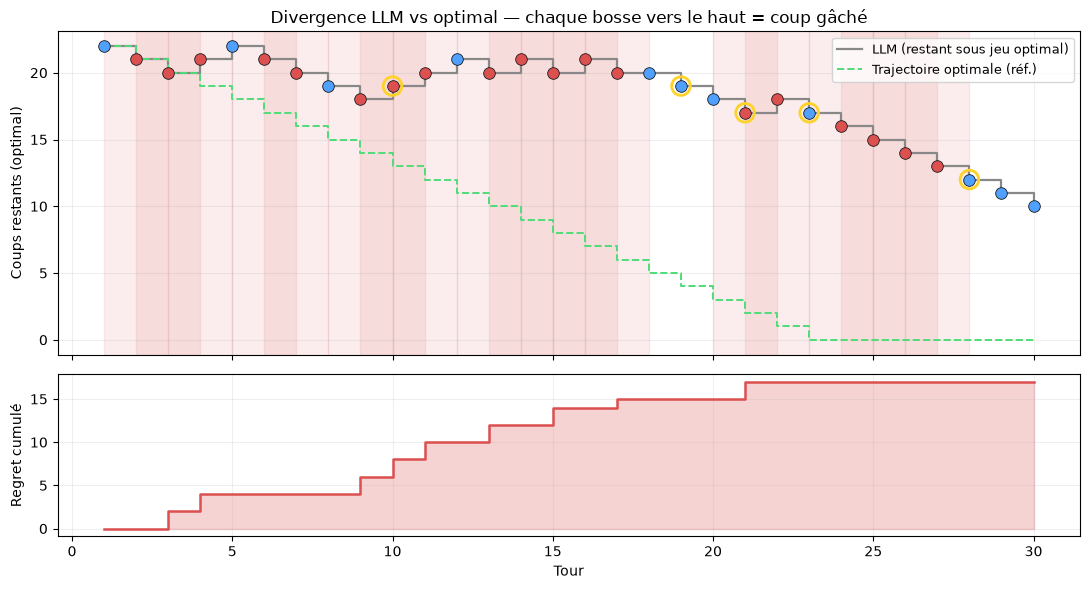

In [15]:
optimal_steps = summary["optimal_steps"]
cmp["regret_cum"] = cmp["regret"].cumsum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

# ── Haut : coups optimaux restants depuis la case courante du LLM ─────────────
ax1.step(cmp["turn"], cmp["opt_steps_remaining"], where="post",
         color="#888", lw=1.6, label="LLM (restant sous jeu optimal)")
ref = [max(optimal_steps - (t - 1), 0) for t in cmp["turn"]]
ax1.step(cmp["turn"], ref, where="post", color="#50dc78", lw=1.4, ls="--",
         label="Trajectoire optimale (réf.)")

for _, r in cmp.iterrows():
    col = "#dc5050" if not r["match"] else "#50a0ff"     # rouge = divergence
    ax1.scatter(r["turn"], r["opt_steps_remaining"], s=70, color=col, zorder=5,
                edgecolor="#1a1a1a", linewidth=0.6)
    if r["gold"]:                                        # or ramassé : cercle jaune
        ax1.scatter(r["turn"], r["opt_steps_remaining"], s=180, facecolor="none",
                    edgecolor="#ffd228", linewidth=2, zorder=4)

for _, r in cmp[~cmp["match"]].iterrows():              # bandes sur les divergences
    ax1.axvspan(r["turn"] - 1, r["turn"] + 1, color="#dc5050", alpha=0.10)

ax1.set_ylabel("Coups restants (optimal)")
ax1.set_title("Divergence LLM vs optimal — chaque bosse vers le haut = coup gâché")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(alpha=0.2)

# ── Bas : regret cumulé ────────────────────────────────────────────────────────
ax2.fill_between(cmp["turn"], cmp["regret_cum"], step="post", color="#dc5050", alpha=0.25)
ax2.step(cmp["turn"], cmp["regret_cum"], where="post", color="#dc5050", lw=1.8)
ax2.set_ylabel("Regret cumulé")
ax2.set_xlabel("Tour")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [16]:
# ═══ Analyse des justifications par direction ═════════════════════════════════
import re
from npc_solver import compare_run

RX_ANTILOOP = re.compile(r"tourn\w+ en rond|boucle|cercle|répét|repet|redondan|circulair|tourni", re.I)
RX_HESITATE = re.compile(r"cependant|correction|mais en|toutefois|réponse finale|alternative", re.I)

frames = []
for r in runs:                                        # depuis list_runs()
    data = json.loads(Path(r).read_text(encoding="utf-8"))
    d = pd.DataFrame(data["decision_log"])
    d["run"] = Path(r).stem[-19:]
    if "initial_map" in data:
        _, rows = compare_run(np.array(data["initial_map"]), data["decision_log"])
        d = d.merge(pd.DataFrame(rows)[["turn", "opt_dir", "match", "regret"]], on="turn", how="left")
    else:
        d[["opt_dir", "match", "regret"]] = None
    frames.append(d)

full = pd.concat(frames, ignore_index=True)
full["n_words"]    = full["reason"].str.split().str.len()
full["antiloop"]   = full["reason"].str.contains(RX_ANTILOOP)
full["hesitation"] = full["reason"].str.contains(RX_HESITATE)

has_cmp = full.dropna(subset=["match"]).copy()
has_cmp["match"] = has_cmp["match"].astype(bool)

print("=== Par direction ===")
display(has_cmp.groupby("direction").agg(
    n=("turn", "size"), mots_moy=("n_words", "mean"),
    pct_antiloop=("antiloop", "mean"), pct_hesit=("hesitation", "mean"),
    pct_match=("match", "mean"), regret_moy=("regret", "mean"),
    pct_or=("gold", "mean")).round(2))

print("=== Mention anti-boucle : impact ===")
display(has_cmp.groupby("antiloop").agg(
    n=("turn", "size"), mots_moy=("n_words", "mean"),
    pct_match=("match", "mean"), regret_moy=("regret", "mean")).round(2))

=== Par direction ===


,n,mots_moy,pct_antiloop,pct_hesit,pct_match,regret_moy,pct_or
direction,,,,,,,
DOWN,113,80.38,0.44,0.17,0.65,0.59,0.11
LEFT,70,95.71,0.53,0.26,0.33,0.77,0.13
RIGHT,80,77.16,0.51,0.12,0.45,0.21,0.24
UP,96,65.72,0.31,0.14,0.68,0.64,0.11


=== Mention anti-boucle : impact ===


,n,mots_moy,pct_match,regret_moy
antiloop,,,,
False,201,42.26,0.53,0.6
True,158,125.13,0.58,0.5
